# `dtd-unifying` — Cantarella & Cascetta's (1995) unifying day-to-day process

**What.** One two-equation process — a cost-learning filter p ← (1−w) p + w t(v) plus a choice update where a fraction α reconsiders at forecast costs — whose choice map is gated per scenario (AON best response ⇒ Wardrop UE on deterministic tasks; Dial logit ⇒ logit SUE on SUE tasks). The unifying node of the day-to-day family.

**Why it is in the benchmark.** It reduces exactly to `dtd-horowitz` (α=1) and to `msa` (w=1, α=1), and exhibits the joint (α, w) flip-stability boundary: at (1,1) it limit-cycles while EITHER cost memory OR choice inertia restores convergence (C&C's headline result). See the
[model compendium](../../docs/MODELS.md) and the certificate design in
[docs/ARCHITECTURE.md](../../docs/ARCHITECTURE.md) (P1).

**Scope.** Runs the process on a built-in scenario and certifies the result; it does
not benchmark day-to-day models against each other. Reference: Cantarella & Cascetta (1995), *Transportation Science* 29(4).

**Canon.** `[cantarella1995dynamic]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every scored
quantity below is recomputed live by the P1 `Evaluator` from the flows the model
emitted, in the cell where it is claimed. Model self-reports (the per-day gap/residual,
the Lyapunov value) are shown only as provenance and diffed against the certificate,
exactly as the harness treats them ([README](../../README.md), *Certified, not
self-reported*).

In [1]:
# Setup. `dtd-unifying` is a core day-to-day model: a plain `pip install -e .` suffices —
# no optional extra, so no guard cell. The inline backend is Agg-based (headless CI
# renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it silently
# suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    Budget,
    CostSmoothingSUEModel,
    Evaluator,
    MSAModel,
    RngBundle,
    Trace,
    UnifyingDTDModel,
    braess_scenario,
    two_route_scenario,
    viz,
)

## The scenario

The built-in two-route logit-SUE anchor (demand 4, dispersion θ=0.5): route A cost 2+f_A,
route B cost 1.5+2 f_B. Its rest point is the binary-logit stochastic user equilibrium,
recomputed analytically in the certify cell — NOT the deterministic Wardrop UE.

In [2]:
scenario = two_route_scenario()
net = scenario.network
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"links         : {net.n_links}  (tail→head: "
      + ", ".join(f"{i}->{j}" for i, j in zip(net.init_node, net.term_node)) + ")")
print(f"total demand  : {scenario.demand.total}")
print("task          : logit SUE, θ=0.5")

scenario      : tworoute
content hash  : 9b98e58b339b702f…
links         : 4  (tail→head: 1->3, 3->2, 1->4, 4->2)
total demand  : 4.0
task          : logit SUE, θ=0.5


## Run the adjustment process

The model contract ([CONTRIBUTING.md](../../CONTRIBUTING.md)): a model receives
`(scenario, budget, rng, trace)` and records one checkpoint per day — here a *budget
iteration is a day*. Everything the model writes into `self_report` (the per-day
gap/residual, the Lyapunov value) is provenance, not a score.

In [3]:
bundle_trace = Trace()
model = UnifyingDTDModel()  # default (memory_weight=0.5, reconsideration_rate=0.5)
# Full horizon so both the SUE residual and the forecast (perceived-cost) gap vanish.
model.solve(scenario, Budget(iterations=500), RngBundle(0), bundle_trace)
final = bundle_trace.final
print(f"model            : {model.name}")
print(f"days simulated   : {final.coords.iterations}  "
      f"({final.coords.sp_calls} shortest-path calls)")
print(f"emitted flows    : {np.round(final.link_flows, 6)}")
print(f"self-reported residual: {final.self_report['sue_fixed_point_residual']:.3e}  (provenance only)")

model            : dtd-unifying
days simulated   : 500  (1001 shortest-path calls)
emitted flows    : [2.299096 2.299096 1.700904 1.700904]
self-reported residual: 3.331e-16  (provenance only)


## Certify (P1) — the SUE fixed point AND the descent

The harness recomputes the ADR-001 Dial-STOCH residual from the emitted flows. Certified
here: (1) the terminal flows are the logit SUE — residual → 0 with the analytic binary-
logit anchor recomputed in-cell, while the *deterministic* UE gap stays positive (a
descriptive column, like `sue-msa`); (2) the model's Lyapunov / provenance signature.

In [4]:
from scipy.optimize import brentq
evaluator = Evaluator(scenario)
metrics = evaluator.evaluate(final.link_flows)
residual = metrics["sue_fixed_point_residual"]
print(f"certified SUE residual : {residual:.3e}")
print(f"feasible               : {metrics['feasible']:.0f}")
print(f"UE relative gap        : {metrics['relative_gap']:.3f}  (stays >0 — logit SUE ≠ deterministic UE)")
assert metrics["feasible"] == 1.0
assert residual < 1e-6
assert metrics["relative_gap"] > 0.01  # descriptive column: not the deterministic UE

# Analytic binary-logit SUE anchor, recomputed in-cell (θ=0.5, demand 4): the root of
# f_A = D / (1 + exp(θ(c_A − c_B))), c_A = 2 + f_A, c_B = 1.5 + 2(4 − f_A).
def _resid(f_a):
    c_a, c_b = 2.0 + f_a, 1.5 + 2.0 * (4.0 - f_a)
    return f_a - 4.0 / (1.0 + np.exp(0.5 * (c_a - c_b)))
f_a = brentq(_resid, 0.0, 4.0, xtol=1e-12)
ref_flows = np.array([f_a, f_a, 4.0 - f_a, 4.0 - f_a])
print(f"analytic logit SUE f_A : {f_a:.6f}")
assert np.allclose(final.link_flows, ref_flows, atol=1e-4)
# Honesty (P1): the model self-reports the SAME residual the harness recomputes.
assert np.isclose(
    final.self_report["sue_fixed_point_residual"], residual, rtol=1e-9, atol=1e-12
)
# The perceived-cost (forecast) gap vanishes at rest (provenance).
pgap = [s.self_report["perceived_cost_gap"] for s in bundle_trace]
assert max(pgap) > 1.0 and pgap[-1] < 1e-6
print(f"perceived-cost gap     : {max(pgap):.3g} → {pgap[-1]:.2e}")

# DISTINCTIVE (Cantarella & Cascetta 1995): joint (α, w) flip stability. At (α,w)=(1,1)
# — no choice inertia, no cost memory — the process limit-cycles; EITHER form of inertia
# restores convergence. The default (0.5, 0.5) is stable (certified above); the contrast:
cyc = Trace()
UnifyingDTDModel(memory_weight=1.0, reconsideration_rate=1.0).solve(
    scenario, Budget(iterations=400), RngBundle(0), cyc
)
print(f"(α,w)=(1,1) residual   : {cyc.final.self_report['sue_fixed_point_residual']:.3f}  (limit cycle)")
assert cyc.final.self_report["sue_fixed_point_residual"] > 1.0

certified SUE residual : 3.331e-16
feasible               : 1
UE relative gap        : 0.056  (stays >0 — logit SUE ≠ deterministic UE)
analytic logit SUE f_A : 2.299096
perceived-cost gap     : 2.79 → 0.00e+00
(α,w)=(1,1) residual   : 3.323  (limit cycle)


## The exact reductions: α=1 → `dtd-horowitz`, (w=1, α=1) → `msa`

The docstring's central claim — this model UNIFIES the previously separate
day-to-day strands — is not narrative unless it is checkpoint-exact, and the
claim is stronger than "reaches the same fixed point": it is **day-by-day
trajectory identity**, verified below at `rtol=atol=1e-12`. `reconsideration_rate=1.0`
(everyone reconsiders daily) collapses the choice update `v <- v + alpha (y -
v)` to `v <- y`, which — on the SAME stochastic-branch anchor, at the SAME
memory weight `w` — is `dtd-horowitz`'s own recursion verbatim; likewise
`memory_weight=1.0` collapses the cost filter to `p <- t(v)` (no memory), and
at `alpha=1` too the deterministic branch's annealed step `alpha/n = 1/n` IS
`msa`'s own iterate sequence on the SAME Braess anchor. Both hold up to a
**one-checkpoint index offset**: `dtd-unifying` updates `p` at the START of
each loop iteration (folding its day-0 bootstrap into day 1's update), while
`dtd-horowitz`/`msa` record-then-update at the END of theirs — a
loop-boundary bookkeeping difference, not an approximation (RNG plays no role
in either process; both are deterministic recursions). Mirrors
`tests/test_dtd_unifying.py`'s `test_reduces_to_dtd_horowitz_at_alpha_one` /
`test_reduces_to_msa_at_unit_memory_and_alpha` verbatim.

In [5]:
# α=1 → dtd-horowitz, stochastic branch, SAME two-route SUE anchor, SAME w=0.5.
unifying_h = Trace()
UnifyingDTDModel(memory_weight=0.5, reconsideration_rate=1.0).solve(
    scenario, Budget(iterations=30), RngBundle(0), unifying_h
)
horowitz = Trace()
CostSmoothingSUEModel(smoothing_weight=0.5).solve(
    scenario, Budget(iterations=31), RngBundle(0), horowitz
)
# One-day offset: dtd-unifying's checkpoint k is dtd-horowitz's checkpoint k+1.
max_diff_h = max(
    np.abs(unifying_h.checkpoints[k].link_flows - horowitz.checkpoints[k + 1].link_flows).max()
    for k in range(30)
)
print(f"dtd-unifying(α=1) vs dtd-horowitz, max |Δflow| over 30 days : {max_diff_h:.2e}")
for k in range(30):
    np.testing.assert_allclose(
        unifying_h.checkpoints[k].link_flows,
        horowitz.checkpoints[k + 1].link_flows,
        rtol=1e-12, atol=1e-12,
    )

# (w=1, α=1) → msa, deterministic branch, SAME Braess anchor.
braess = braess_scenario()
unifying_m = Trace()
UnifyingDTDModel(memory_weight=1.0, reconsideration_rate=1.0).solve(
    braess, Budget(iterations=40), RngBundle(0), unifying_m
)
msa = Trace()
MSAModel().solve(braess, Budget(iterations=41), RngBundle(0), msa)
max_diff_m = max(
    np.abs(unifying_m.checkpoints[k].link_flows - msa.checkpoints[k + 1].link_flows).max()
    for k in range(40)
)
print(f"dtd-unifying(w=1,α=1) vs msa, max |Δflow| over 40 days      : {max_diff_m:.2e}")
for k in range(40):
    np.testing.assert_allclose(
        unifying_m.checkpoints[k].link_flows,
        msa.checkpoints[k + 1].link_flows,
        rtol=1e-12, atol=1e-12,
    )


dtd-unifying(α=1) vs dtd-horowitz, max |Δflow| over 30 days : 0.00e+00
dtd-unifying(w=1,α=1) vs msa, max |Δflow| over 40 days      : 0.00e+00


## Visualize

Both figures come from `tabench.viz`, the house visualizer — every plotted number is one
certified above. Left/top: the certified terminal link flows on the network. Right/bottom:
the emitted flows against the fixed point recomputed in the certify cell — points on the
`y = x` guide mean the day-to-day process settled on it link-for-link.

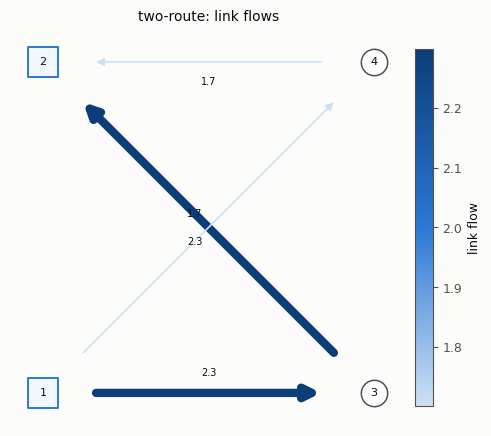

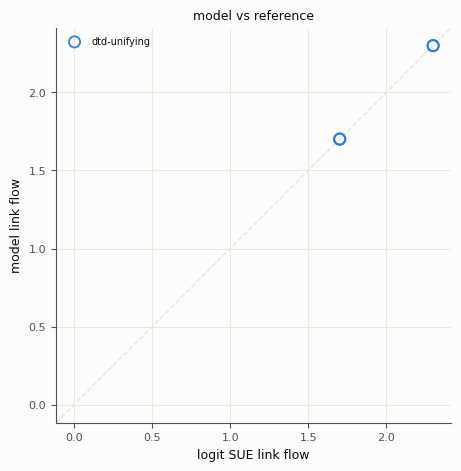

In [6]:
# Certified terminal flows on the network (house style via tabench.viz).
display(viz.plot_network_flows(net, final.link_flows))

# Emitted flows vs the logit SUE recomputed above (off-diagonal == not settled).
display(viz.plot_flow_scatter(("logit SUE", ref_flows), {"dtd-unifying": final.link_flows}))

## Takeaways & pointers

- **Certified, not self-reported.** The residual came from `Evaluator`; the contrast run at (α,w)=(1,1) certified an O(1) limit cycle — either form of inertia is what makes the default converge.
- **The day-to-day signature is the point.** A UE/SUE *solver* gives you the fixed
  point; a day-to-day *model* gives you the adjustment path to it.
- **Both exact reductions are certified above, checkpoint-by-checkpoint** (not just at the terminal flow): [`dtd-horowitz`](05-dtd-horowitz.ipynb) (α=1) and [`msa`](../01-static/02-msa.ipynb) (w=α=1). The stochastic process [`dtd-stochastic`](06-dtd-stochastic.ipynb) is the OTHER generalization axis (a genuinely stochastic process, vs this model's deterministic recursion over a probabilistic choice map).
- **Where next.** the lineage in the [model compendium](../../docs/MODELS.md).